In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tiruvarur.csv")
df = df.sort_values("time")

In [3]:
df["time"] = pd.to_datetime(df["time"])
feature_cols = [
    "temperature",
    "dewpoint",
    "pressure",
    "wind_u",
    "wind_v",
    "cloud_cover",
    "humidity"
]

X = df[feature_cols]
y = df["rain_mm"]

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

In [7]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("R²     :", round(r2, 4))
print("MSE    :", round(mse, 4))
print("RMSE   :", round(rmse, 4))
print("MAE    :", round(mae, 4))
print("MedAE  :", round(medae, 4))

Model Evaluation Results
R²     : 0.0477
MSE    : 0.224
RMSE   : 0.4733
MAE    : 0.1298
MedAE  : 0.0666


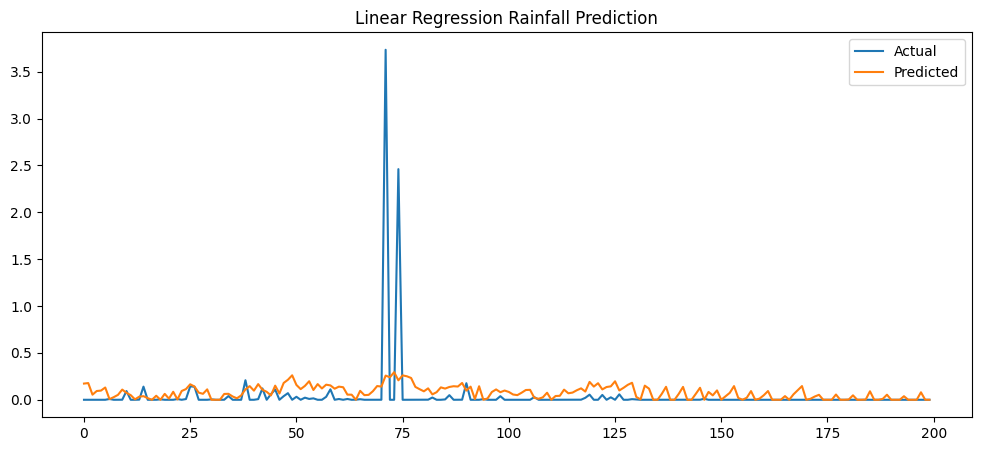

In [8]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Linear Regression Rainfall Prediction")
plt.show()

In [9]:
new_data = pd.DataFrame([{
    "temperature": 30.5,
    "dewpoint": 25.2,
    "pressure": 1008.5,
    "wind_u": 2.1,
    "wind_v": -1.3,
    "cloud_cover": 0.75,
    "humidity": 82.4
}])

# Predict
predicted_rain = model.predict(new_data)

predicted_rain = np.clip(predicted_rain, 0, None)

print("\nPredicted Rainfall for Given Input:")
print(f"{predicted_rain[0]:.4f} mm")


Predicted Rainfall for Given Input:
0.2715 mm
